# K Mean Clustering

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

%matplotlib inline

In [107]:
df = pd.read_csv("../data/processed/Processed_Leads.csv")
df.head(10)

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Other,Lead Source_Reference,Do Not Email_Yes,Do Not Call_Yes,Last Activity_Email Opened,Last Activity_Olark Chat Conversation,Last Activity_Other,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Country_Other,Country_Unknown,Specialization_Human Resource Management,Specialization_Marketing Management,Specialization_Operations Management,Specialization_Other,Specialization_Unknown,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Unknown,What is your current occupation_Working Professional,What matters most to you in choosing a course_Flexibility & Convenience,What matters most to you in choosing a course_Other,What matters most to you in choosing a course_Unknown,Search_Yes,Newspaper Article_Yes,X Education Forums_Yes,Newspaper_Yes,Digital Advertisement_Yes,Through Recommendations_Yes,Tags_Interested in other courses,Tags_Other,Tags_Ringing,Tags_Unknown,Tags_Will revert after reading the email,A free copy of Mastering The Interview_Yes
0,1.860674,-0.791863,-0.713593,-0.889974,-1.098699,-1.059333,-0.290263,-0.077382,-0.010404,-0.670891,2.065177,-0.377777,-0.208797,-0.247663,-0.293755,-0.014714,-0.769597,-0.343070,-0.351678,3.665720,-0.650102,-0.179043,1.659690,-0.317881,-0.315813,-0.23994,-0.641689,1.316711,-0.032915,-0.041649,-0.152499,0.806226,-0.640849,-0.287625,-0.014714,-0.010404,-0.644043,-0.038954,-0.014714,-0.010404,-0.010404,-0.020811,-0.027535,4.124524,-0.463498,-0.386889,-0.754692,-0.537645,-0.674285
1,1.860289,-0.791863,0.324018,0.339972,0.066441,-1.059333,-0.290263,-0.077382,-0.010404,-0.670891,-0.484220,2.647061,-0.208797,-0.247663,-0.293755,-0.014714,1.299381,-0.343070,-0.351678,-0.272798,-0.650102,-0.179043,-0.602522,-0.317881,-0.315813,-0.23994,-0.641689,1.316711,-0.032915,-0.041649,-0.152499,0.806226,-0.640849,-0.287625,-0.014714,-0.010404,-0.644043,-0.038954,-0.014714,-0.010404,-0.010404,-0.020811,-0.027535,-0.242452,-0.463498,2.584724,-0.754692,-0.537645,-0.674285
2,1.860246,1.262845,-0.298549,1.905689,-0.166587,0.943990,-0.290263,-0.077382,-0.010404,-0.670891,-0.484220,-0.377777,-0.208797,-0.247663,-0.293755,-0.014714,1.299381,-0.343070,-0.351678,-0.272798,-0.650102,-0.179043,-0.602522,-0.317881,-0.315813,-0.23994,1.558387,-0.759468,-0.032915,-0.041649,6.557439,-1.240347,-0.640849,-0.287625,-0.014714,-0.010404,-0.644043,-0.038954,-0.014714,-0.010404,-0.010404,-0.020811,-0.027535,-0.242452,-0.463498,-0.386889,-0.754692,1.859962,1.483053
3,1.859905,-0.791863,-0.506071,-0.333396,-0.632643,0.943990,-0.290263,-0.077382,-0.010404,-0.670891,-0.484220,-0.377777,-0.208797,-0.247663,-0.293755,-0.014714,-0.769597,-0.343070,2.843509,-0.272798,-0.650102,-0.179043,-0.602522,-0.317881,-0.315813,-0.23994,1.558387,-0.759468,-0.032915,-0.041649,-0.152499,0.806226,-0.640849,-0.287625,-0.014714,-0.010404,-0.644043,-0.038954,-0.014714,-0.010404,-0.010404,-0.020811,-0.027535,-0.242452,-0.463498,2.584724,-0.754692,-0.537645,-0.674285
4,1.858281,1.262845,-0.298549,1.715905,-0.632643,0.943990,-0.290263,-0.077382,-0.010404,1.490556,-0.484220,-0.377777,-0.208797,-0.247663,-0.293755,-0.014714,-0.769597,-0.343070,-0.351678,-0.272798,-0.650102,-0.179043,-0.602522,-0.317881,-0.315813,-0.23994,-0.641689,1.316711,-0.032915,-0.041649,-0.152499,0.806226,-0.640849,-0.287625,-0.014714,-0.010404,-0.644043,-0.038954,-0.014714,-0.010404,-0.010404,-0.020811,-0.027535,-0.242452,-0.463498,-0.386889,-0.754692,1.859962,-0.674285
5,1.858238,-0.791863,-0.713593,-0.889974,-1.098699,-1.059333,-0.290263,-0.077382,-0.010404,-0.670891,2.065177,-0.377777,-0.208797,-0.247663,-0.293755,-0.014714,-0.769597,2.914859,-0.351678,-0.272798,

**Calculated inertia with different values of K for KMeans to fine the optimal value of K**

In [108]:
inertia = []
for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42).fit(df)
    inertia.append(model.inertia_.__round__(2))
inertia

[415334.72,
 397410.93,
 383395.67,
 362357.9,
 353172.46,
 342839.3,
 333564.4,
 323292.38,
 317721.07]

K=5 shows a significant dip, as shown below, validating the elbow effect making it the ideal choice for K

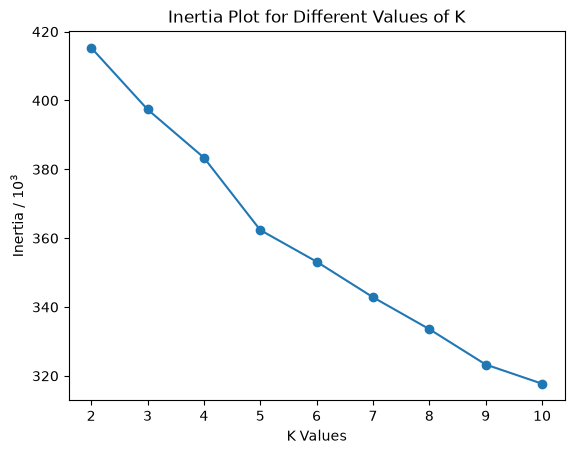

In [109]:
plt.plot(list(range(2,11)),np.array(inertia)/1000,marker="o")
plt.xlabel("K Values")
plt.ylabel("Inertia / $10^3$") # LaTeX notation
plt.title("Inertia Plot for Different Values of K")
plt.show()

In [110]:
cluster_labels = KMeans(n_clusters=5,random_state=42).fit_predict(df)

**Adding the cluster data to the dataset**

In [111]:
df_clean = pd.read_csv("../data/interim/Cleaned_Leads.csv")
df_clean["Cluster"] = cluster_labels
df_clean["Cluster"].value_counts().sort_index()

Cluster
0    4374
1    1703
2     592
3    1851
4     720
Name: count, dtype: int64

**Interpreting the 5 cluster representations**

Based on the values from object fields and mean from numeric fields we can deduce that : -
- **Cluster 0 (Standard Traffic):** Majority origin is "landing page submission" with "Google" and "direct traffic" sources evenly combined. Current occupations and specializations are either "unknown" or "unemployed", and 100% chose "better career prospects". In terms of behavior, they spend roughly 8 to 11 minutes on the site viewing about 3 pages suggesting it might be a general campaign.
- **Cluster 1 (Passive Chat Inquiries):** Origin is mostly "API" and source is primarily "Olark chat". About 50% chose "better career prospects" while the rest are mostly "unknown". Page views per visit are less than 0.5 and almost everyone in this group spent under 30 seconds on the site. It has a low 23% conversion rate suggesting that this cluster is specially made considering the origin and source for Olark chat users, and the low time spent suggests they weren't much interested.
- **Cluster 2 (Marketing Niche Professionals):** Very similar to cluster 0 in origin, source, and behavior. Also spending roughly 8 to 11 minutes on the site viewing about 3 pages. Interestingly, this cluster is fully "marketing management" specialization with mostly "unemployed" and a minor portion "working professional". Most also chose "better career prospects". This differentiates it from cluster 0 because it is explicitly targeted to marketing management people.
- **Cluster 3 (Window Shoppers):** Nothing special about origin and source, with a minor portion of "finance management" specialization and 98% occupation is "unknown". They have the exact same behavior as clusters 0 and 2, spending roughly 8 to 11 minutes on the site viewing about 3 pages. This cluster might also be a generalized campaign, but they just browse without converting well.
- **Cluster 4 (High Velocity Conversions):** Origin is "lead add form" for almost all, mostly coming from "direct Lead Add Forms" or "Referrals". Unlike the rest with a majority from India, its majority country is "unknown" with a minor portion specialization in "HR management" and about one fourth as "working professional". Almost all chose "better career prospect". Page views are less than 0.5 but the time spent is about 223 seconds, and it converts at 92.6% rate. They exactly knew what they were looking for explaining the low page views and high conversion. This one might target international working professionals.

In [112]:
df_clean.groupby("Cluster").mean(numeric_only=True)

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit
Cluster,,,,,
0,616294.101052,0.432327,4.632830,669.598080,3.180096
1,614940.636524,0.233118,0.183206,29.132120,0.107322
2,615768.866554,0.520270,4.108108,706.793919,2.928497
3,620873.273906,0.160994,4.461912,512.506213,3.051243
4,619632.283333,0.926389,0.702778,223.370833,0.428778


In [113]:
for cluster in set(df_clean["Cluster"]):
    cluster_data = df_clean[df_clean["Cluster"]==cluster]
    text_cols = cluster_data.select_dtypes(include=["object","str"]).columns
    print("Cluster: ",cluster,"\n")
    for col in text_cols:
        print((cluster_data[col].value_counts(normalize=True)*100).round(2).head(3))
        print("\n")
    print("\n")

Cluster:  0 

Lead Origin
Landing Page Submission    72.38
API                        27.57
Lead Import                 0.05
Name: proportion, dtype: float64


Lead Source
Google            40.79
Direct Traffic    37.17
Organic Search    18.79
Name: proportion, dtype: float64


Do Not Email
No     92.25
Yes     7.75
Name: proportion, dtype: float64


Do Not Call
No    100.0
Name: proportion, dtype: float64


Last Activity
Email Opened    38.68
SMS Sent        33.61
Other            9.95
Name: proportion, dtype: float64


Country
India      94.86
Other       4.16
Unknown     0.98
Name: proportion, dtype: float64


Specialization
Other                 43.30
Unknown               20.67
Finance Management    14.97
Name: proportion, dtype: float64


What is your current occupation
Unemployed              87.77
Working Professional     9.26
Student                  2.54
Name: proportion, dtype: float64


What matters most to you in choosing a course
Better Career Prospects    100.0
Name: pro

**Visually comparing the behaviors or numeric columns for each cluster.**

The plots validate what we deduced before.
- Clusters 0, 2, and 3: Represent the massive baseline population of normal browsers with nearly identical behavioral spreads.
- Clusters 1 and 4: Act as two extreme, highly distinct outlier groups hidden within the broader dataset.

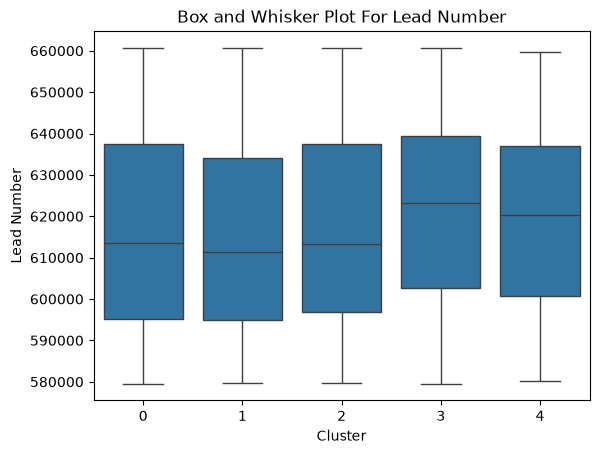

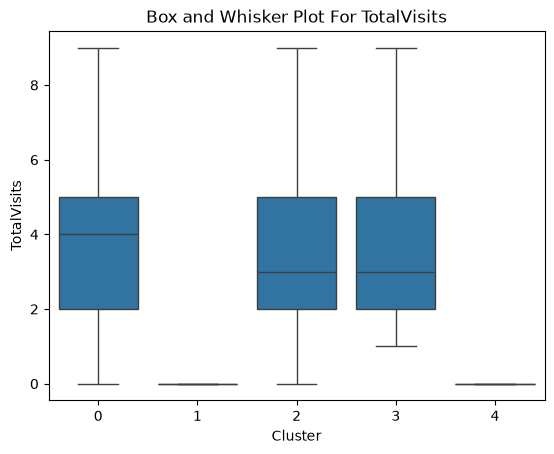

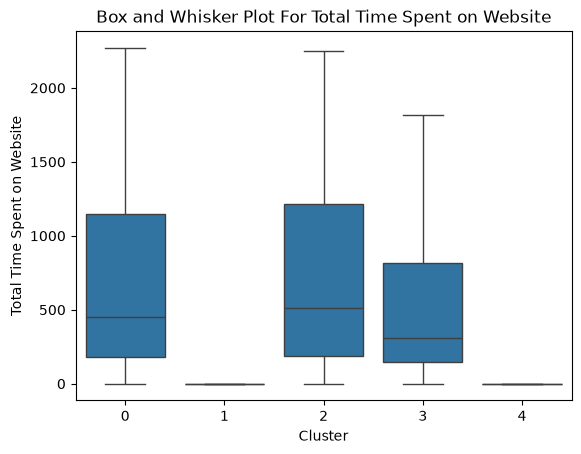

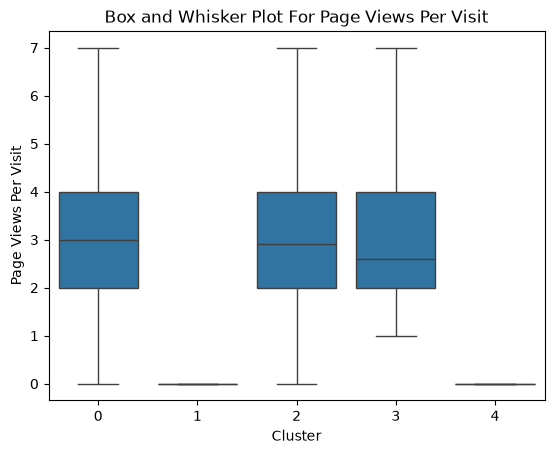

In [114]:
cont_cols = cluster_data.select_dtypes(include="number").drop(columns=["Converted","Cluster"])
for col in cont_cols.columns:
    sns.boxplot(data=df_clean,x="Cluster",y=col,showfliers=False)
    plt.title(f"Box and Whisker Plot For {col}")
    plt.show()

**Renaming the clusters to meaningful names understood by non-technical people.** 

In [ ]:
df_clean["Cluster"] = df_clean["Cluster"].replace({0:"Normal Traffic",1:"Passive Chat Inquiries",
                                                   2:"Marketing Niche Professionals",3:"Window Shoppers",4:"High Velocity Conversions"})
df_clean.head(10)

,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Cluster
0,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,Unknown,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,No,No,No,No,Passive Chat Inquiries
1,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,No,No,Normal Traffic
2,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Other,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,No,Yes,Normal Traffic
3,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Other,India,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,No,No,No,No,Normal Traffic
4,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Unknown,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,No,No,Normal Traffic
5,660680,API,Olark Chat,No,No,0,0.0,0,0.0,Olark Chat Conversation,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,No,No,Passive Chat Inquiries
6,660673,Landing Page Submission,Google,No,No,1,2.0,1640,2.0,Email Opened,India,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,No,No,No,No,Normal Traffic
7,660664,API,Olark Chat,No,No,0,0.0,0,0.0,Olark Chat Conversation,Unknown,Unknown,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,No,No,Passive Chat Inquiries
8,660624,Landing Page Submission,Direct Traffic,No,No,0,2.0,71,2.0,Email Opened,India,Other,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,No,Yes,Window Shoppers
9,660616,API,Google,No,No,0,4.0,58,4.0,Email Opened,India,Finance Management,Unknown,Unknown,No,No,No,No,No,No,No,No,Unknown,No,No,No,No,Window Shoppers


In [ ]:
df_clean.to_csv("../data/segmented/Segmented_Leads.csv",index=False)